# PyDESeq2 differential expression analysis: ERBB2 OE vs WT, sham and MI

**Data**

4 animals for each experimental group were used (WT Sham, ERBB2 - OE Sham, WT MI, ERBB2 - OE MI).
Cardiomyocyte-restricted Dox-inducible overexpression of caErbb2 was generated as before.
Doxycycline (TD02503, Harlan Laboratories) was administered in the food to repress transgene expression.
https://www.nature.com/articles/s41556-020-00588-4

**Design**
The samplesheet has two factors, `genotype` (WT / OE) and `condition` (SHAM / MI). They are merged into a single 4-level `group` factor (`WT_SHAM`, `OE_SHAM`, `WT_MI`, `OE_MI`) and the model `~ group` is fitted **once** on all 16 samples, so dispersions are estimated with all the data. Two contrasts are then extracted:
- `sham`: OE_SHAM vs WT_SHAM (effect of ERBB2 OE at baseline)
- `MI`: OE_MI vs WT_MI (effect of ERBB2 OE after infarction)

log2FC is always `OE / WT`, so a positive value means higher in ERBB2-OE. Each contrast is exported as its own table, ready for the CORNETO notebook.

**Inputs**
- Raw (un-normalised) counts, genes x samples (nf-core `salmon.merged.gene_counts.tsv`). Salmon counts are non-integer and are rounded.
- `samplesheet.csv` with `sample`, `genotype` and `condition` columns.

**Conventions kept from the AXL analysis**
- Genes with fewer than 30 reads across all samples are removed before fitting.
- Significance threshold: adjusted p < 0.05.
- `stat` is the Wald statistic from the un-shrunk model (the CORNETO notebook runs decoupler on `stat`). LFC shrinkage is not applied.

**Things to check**
- Gene identifiers: the CORNETO notebook expects **mouse gene symbols**. nf-core tables have `gene_id` (Ensembl) and `gene_name`; the loader below uses `gene_name` as index.
- Use the PCA in step 5 to spot outlier samples. Document any exclusion in the config cell rather than editing the count file.

In [3]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pydeseq2
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

print('pydeseq2', pydeseq2.__version__)

pydeseq2 0.5.0


## 1. Configuration (edit this cell only)

In [ ]:
root_dir = '/mnt/sds-hd/sd22b002/projects/ines/axl_networks'
project_dir = f'{root_dir}/results/erbb2'    # nf-core run output

dataset_id = 'GSE144391_ERBB2'   # prefix for output file names
counts_file = f'{project_dir}/star_salmon/salmon.merged.gene_counts.tsv'
counts_sep = '\t'
counts_orientation = 'genes_x_samples'   # or 'samples_x_genes'
gene_name_col = 'gene_name'      # nf-core: symbols column next to the Ensembl gene_id index; None if absent

# --- sample annotation ---------------------------------------------------
metadata_file = f'{root_dir}/data/downloads/GSE144391_ERBB2/samplesheet.csv'
metadata_sep = ','
metadata_index_col = 'sample'    # column with sample IDs matching the count matrix columns

# two factors are merged into one 'group' factor: f'{genotype}_{condition}'
genotype_col = 'genotype'        # WT / OE
condition_col = 'condition'      # SHAM / MI
group_col = 'group'

# name -> (numerator group, reference group); log2FC = numerator / reference
contrasts = {
    'sham': ('OE_SHAM', 'WT_SHAM'),
    'MI': ('OE_MI', 'WT_MI'),
}
covariates = []                  # extra design columns present in the metadata, e.g. ['batch']
exclude_samples = []             # sample IDs to drop (document why, e.g. PCA outlier)

# --- model / filtering ---------------------------------------------------
min_total_counts = 30            # same filter as the AXL analysis (sum over all samples)
alpha = 0.05
n_cpus = 2

# --- output --------------------------------------------------------------
results_dir = f'{root_dir}/results/erbb2/pydeseq2'
figures_dir = f'{root_dir}/figures'
os.makedirs(results_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

## 2. Load counts and metadata

In [8]:
counts = pd.read_csv(counts_file, sep=counts_sep, index_col=0)
if counts_orientation == 'genes_x_samples':
    # nf-core tables: Ensembl gene_id is the index, gene_name a separate column
    if gene_name_col is not None and gene_name_col in counts.columns:
        counts = counts.set_index(gene_name_col)
    counts = counts.T          # PyDESeq2 wants samples x genes
elif counts_orientation != 'samples_x_genes':
    raise ValueError("counts_orientation must be 'genes_x_samples' or 'samples_x_genes'")
counts.index = counts.index.astype(str)
counts.columns = counts.columns.astype(str)

# sample annotation, with the two factors merged into one group factor
metadata = pd.read_csv(metadata_file, sep=metadata_sep, index_col=metadata_index_col)
metadata.index = metadata.index.astype(str)
metadata[group_col] = metadata[genotype_col].astype(str) + '_' + metadata[condition_col].astype(str)

# consistency checks
missing_meta = counts.index.difference(metadata.index)
missing_counts = metadata.index.difference(counts.index)
if len(missing_meta) or len(missing_counts):
    print('In counts but not metadata (dropped):', list(missing_meta))
    print('In metadata but not counts (dropped):', list(missing_counts))
keep = counts.index.intersection(metadata.index).difference(exclude_samples)
counts, metadata = counts.loc[keep], metadata.loc[keep]

# duplicated gene symbols: sum them
if counts.columns.duplicated().any():
    print(f'Summing {counts.columns.duplicated().sum()} duplicated gene columns')
    counts = counts.T.groupby(level=0).sum().T

# raw counts must be non-negative
counts = counts.apply(pd.to_numeric)
if counts.isna().any().any() or (counts < 0).any().any():
    raise ValueError('Counts contain NaN or negative values')
if (counts % 1 != 0).any().any():
    print('Non-integer counts found (salmon expected counts): rounding')
counts = counts.round().astype(int)

metadata = metadata[[group_col] + covariates].copy()
levels = set(metadata[group_col].unique())
needed = {g for pair in contrasts.values() for g in pair}
assert needed <= levels, f'missing groups: {needed - levels}; levels found: {levels}'

print(f'{counts.shape[0]} samples x {counts.shape[1]} genes')
print(metadata.groupby(group_col).size())

Summing 306 duplicated gene columns
Non-integer counts found (salmon expected counts): rounding
16 samples x 78028 genes
group
OE_MI      4
OE_SHAM    4
WT_MI      4
WT_SHAM    4
dtype: int64


## 3. Filter low-count genes

In [11]:
# Keep only the groups used in the contrasts
metadata = metadata[metadata[group_col].isin(needed)]
counts = counts.loc[metadata.index]

gene_totals = counts.sum(axis=0)
n_before = counts.shape[1]
counts = counts.loc[:, gene_totals >= min_total_counts]
print(f'Genes kept: {counts.shape[1]} / {n_before} (>= {min_total_counts} reads across samples)')

Genes kept: 23854 / 78028 (>= 30 reads across samples)


## 4. Fit the model and run the Wald test

In [13]:
design = '~' + ' + '.join(covariates + [group_col])
print('Design:', design)

try:   # pydeseq2 >= 0.5
    dds = DeseqDataSet(counts=counts, metadata=metadata, design=design,refit_cooks=True)
except TypeError:   # older releases use design_factors
    dds = DeseqDataSet(counts=counts, metadata=metadata, design_factors=covariates + [group_col], refit_cooks=True)
dds.deseq2()   # fitted once; all contrasts below reuse this fit

results = {}
for name, (num, ref) in contrasts.items():
    stat_res = DeseqStats(dds, contrast=[group_col, num, ref], alpha=alpha)
    stat_res.summary()
    results[name] = stat_res.results_df.copy()

Design: ~group
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 20.19 seconds.

Fitting dispersion trend curve...
... done in 0.52 seconds.

Fitting MAP dispersions...
... done in 25.45 seconds.

Fitting LFCs...
... done in 13.27 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 4.90 seconds.



Log2 fold change & Wald test p-value: group OE_SHAM vs WT_SHAM
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_name                                                                       
0610005C13Rik    23.127794       -0.881976  0.284375  -3.101452  1.925740e-03   
0610009E02Rik    56.824622       -0.469660  0.254371  -1.846360  6.483993e-02   
0610009L18Rik   109.401792       -0.165196  0.211709  -0.780301  4.352139e-01   
0610012D04Rik     3.273760       -1.784091  0.770015  -2.316957  2.050609e-02   
0610025J13Rik    15.948565       -1.030676  0.419305  -2.458055  1.396919e-02   
...                    ...             ...       ...        ...           ...   
mt-Ts1         2482.982166       -1.241860  0.098888 -12.558314  3.578757e-36   
mt-Tt             3.139614       -0.639527  0.878936  -0.727615  4.668491e-01   
mt-Tv             3.022622       -2.685528  1.083434  -2.478720  1.318549e-02   
mt-Tw            17.010243       -1.645690  0.

Running Wald tests...


Log2 fold change & Wald test p-value: group OE_MI vs WT_MI
                  baseMean  log2FoldChange     lfcSE       stat        pvalue  \
gene_name                                                                       
0610005C13Rik    23.127794       -0.086833  0.280652  -0.309398  7.570189e-01   
0610009E02Rik    56.824622        0.196597  0.258334   0.761018  4.466462e-01   
0610009L18Rik   109.401792       -0.153632  0.211462  -0.726524  4.675178e-01   
0610012D04Rik     3.273760       -1.373045  0.821552  -1.671283  9.466576e-02   
0610025J13Rik    15.948565       -0.244724  0.421724  -0.580293  5.617171e-01   
...                    ...             ...       ...        ...           ...   
mt-Ts1         2482.982166       -1.029752  0.098916 -10.410327  2.224568e-25   
mt-Tt             3.139614       -1.057485  0.941257  -1.123483  2.612326e-01   
mt-Tv             3.022622       -3.568329  1.296824  -2.751591  5.930659e-03   
mt-Tw            17.010243       -2.129065  0.4682

... done in 4.64 seconds.



In [14]:
results['sham'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Postn,11099.836289,3.670392,0.193556,18.962945,3.452618e-80,7.545006e-76
Ltbp3,2665.657116,1.842225,0.098072,18.784394,1.013367e-78,1.107256e-74
Ckm,26604.718280,-1.783861,0.104113,-17.133899,8.290743e-66,6.039253e-62
Mmp2,6577.069928,2.421372,0.141464,17.116575,1.116548e-65,6.099983e-62
Ctsk,488.135841,2.665371,0.157825,16.888110,5.503777e-64,2.405481e-60
Col6a3,3006.524886,2.876077,0.173729,16.554978,1.473956e-61,5.368394e-58
Ppic,950.569024,1.732751,0.105858,16.368562,3.207032e-60,1.001189e-56
Sparc,34708.904452,2.110330,0.129306,16.320388,7.068503e-60,1.930850e-56
Chpf,1191.862027,1.592032,0.097823,16.274539,1.496413e-59,3.633457e-56


In [15]:
results['MI'].sort_values('padj').head(10)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
gene_name,,,,,,
Gm59392,1642.498350,-0.811801,0.051362,-15.805557,2.848594e-56,5.705165e-52
Ckm,26604.718280,-1.557817,0.104102,-14.964336,1.255705e-50,1.257463e-46
Ndufs8,3237.928458,-0.819883,0.056300,-14.562834,4.840868e-48,3.231763e-44
Cox7a1,6142.896720,-1.499970,0.106024,-14.147455,1.936403e-45,9.695571e-42
Ndufb4c,1374.360277,-1.135883,0.080697,-14.075905,5.341644e-45,2.139649e-41
Frem1,302.006718,4.876229,0.358932,13.585379,4.889942e-42,1.632263e-38
Ndufs7,4818.638621,-0.907178,0.067113,-13.517115,1.239418e-41,3.546152e-38
Gm63444,236.554016,-3.651199,0.270653,-13.490326,1.783113e-41,4.464023e-38
Tmem143,1552.445667,-1.276535,0.099173,-12.871741,6.492167e-38,1.444724e-34


## 5. QC: PCA of normalised counts and result summary

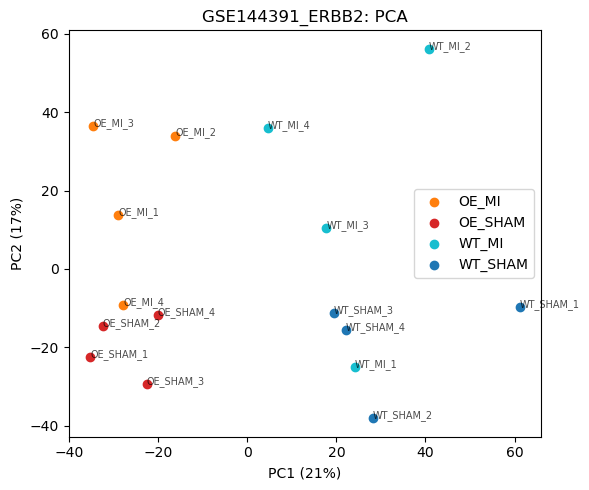

[sham] OE_SHAM vs WT_SHAM: 8226 significant genes (padj < 0.05; 4085 up, 4141 down); padj NA: 2001
[MI] OE_MI vs WT_MI: 5473 significant genes (padj < 0.05; 2684 up, 2789 down); padj NA: 3826


In [16]:
# PCA on log2(normalised counts + 1), top 1000 most variable genes, all groups
norm = pd.DataFrame(dds.layers['normed_counts'], index=counts.index, columns=counts.columns)
logn = np.log2(norm + 1)
top = logn.var(axis=0).sort_values(ascending=False).index[:1000]
X = logn[top] - logn[top].mean(axis=0)
U, S, Vt = np.linalg.svd(X.values, full_matrices=False)
pcs = U * S
var_expl = S**2 / np.sum(S**2)

palette = {'WT_SHAM': 'tab:blue', 'OE_SHAM': 'tab:red', 'WT_MI': 'tab:cyan', 'OE_MI': 'tab:orange'}
fig, ax = plt.subplots(figsize=(6, 5))
for grp in sorted(metadata[group_col].unique()):
    idx = (metadata[group_col] == grp).values
    ax.scatter(pcs[idx, 0], pcs[idx, 1], label=grp, color=palette.get(grp))
for i, name in enumerate(counts.index):
    ax.annotate(name, (pcs[i, 0], pcs[i, 1]), fontsize=7, alpha=0.7)
ax.set_xlabel(f'PC1 ({var_expl[0]:.0%})')
ax.set_ylabel(f'PC2 ({var_expl[1]:.0%})')
ax.set_title(f'{dataset_id}: PCA')
ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_pca.png', dpi=200)
plt.show()

for name, res in results.items():
    num, ref = contrasts[name]
    sig = res['padj'] < alpha
    print(f'[{name}] {num} vs {ref}: {sig.sum()} significant genes (padj < {alpha}; '
          f'{(sig & (res.log2FoldChange > 0)).sum()} up, {(sig & (res.log2FoldChange < 0)).sum()} down); '
          f'padj NA: {res.padj.isna().sum()}')

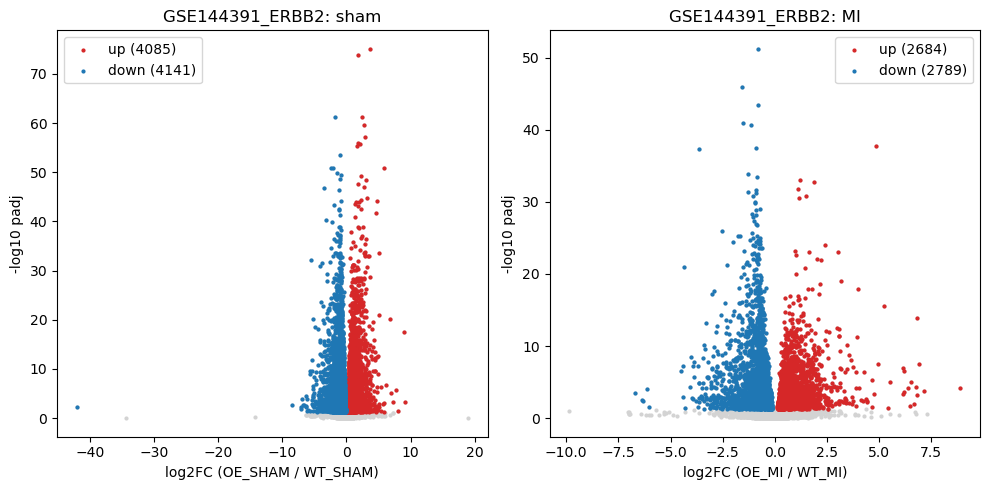

In [17]:
# Volcano plots, one panel per contrast
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5), squeeze=False)
for ax, (name, res) in zip(axes[0], results.items()):
    num, ref = contrasts[name]
    v = res.dropna(subset=['padj']).copy()
    v['neglog10p'] = -np.log10(v['padj'].clip(lower=1e-300))
    up = (v.padj < alpha) & (v.log2FoldChange > 0)
    down = (v.padj < alpha) & (v.log2FoldChange < 0)
    ax.scatter(v.log2FoldChange, v.neglog10p, s=4, color='lightgrey')
    ax.scatter(v.log2FoldChange[up], v.neglog10p[up], s=4, color='tab:red', label=f'up ({up.sum()})')
    ax.scatter(v.log2FoldChange[down], v.neglog10p[down], s=4, color='tab:blue', label=f'down ({down.sum()})')
    ax.set_xlabel(f'log2FC ({num} / {ref})')
    ax.set_ylabel('-log10 padj')
    ax.set_title(f'{dataset_id}: {name}')
    ax.legend()
plt.tight_layout()
plt.savefig(f'{figures_dir}/{dataset_id}_volcano.png', dpi=200)
plt.show()

## 6. Export

Writes one table per contrast, `results/<dataset_id>_<contrast>_deseq2.csv` (e.g. `GSE144391_ERBB2_sham_deseq2.csv`, `GSE144391_ERBB2_MI_deseq2.csv`), in the same layout as the AXL DESeq2 table (first column `Gene.name`), plus one settings file.

In [19]:
cols = ['Gene.name', 'baseMean', 'log2FoldChange', 'lfcSE', 'stat', 'pvalue', 'padj']
settings = []
for name, res in results.items():
    num, ref = contrasts[name]
    out = res.rename_axis('Gene.name').reset_index()
    out = out[cols].sort_values('padj', na_position='last')
    out_file = f'{results_dir}/{dataset_id}_{name}_deseq2.csv'
    out.to_csv(out_file, index=False)
    print('Saved', out_file, out.shape)
    settings.append({
        'dataset_id': dataset_id, 'contrast_name': name, 'design': design,
        'contrast': f'{num} vs {ref}',
        'n_numerator': int((metadata[group_col] == num).sum()),
        'n_reference': int((metadata[group_col] == ref).sum()),
        'excluded_samples': ','.join(exclude_samples),
        'min_total_counts': min_total_counts, 'n_genes_tested': counts.shape[1],
        'n_sig_padj_lt_alpha': int((res.padj < alpha).sum()), 'pydeseq2': pydeseq2.__version__,
    })

# run settings next to the results, for the cross-dataset comparison
pd.DataFrame(settings).to_csv(f'{results_dir}/{dataset_id}_deseq2_settings.csv', index=False)
pd.DataFrame(settings)

Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/pydeseq2/GSE144391_ERBB2_sham_deseq2.csv (23854, 7)
Saved /mnt/sds-hd/sd22b002/projects/ines/axl_networks/pydeseq2/GSE144391_ERBB2_MI_deseq2.csv (23854, 7)


,dataset_id,contrast_name,design,contrast,n_numerator,n_reference,excluded_samples,min_total_counts,n_genes_tested,n_sig_padj_lt_alpha,pydeseq2
0,GSE144391_ERBB2,sham,~group,OE_SHAM vs WT_SHAM,4,4,,30,23854,8226,0.5.0
1,GSE144391_ERBB2,MI,~group,OE_MI vs WT_MI,4,4,,30,23854,5473,0.5.0
